# Prediction Deep-Dive Analysis (XGBoost vs TFT)

This notebook compares raw probabilistic forecasts of **XGBoost** and **TFT** against ground truth for all relevant targets.

Targets covered:
- DA price
- aFRR capacity price (pos/neg)
- aFRR activation price (pos/neg)
- aFRR activation rate (pos/neg)

All plots use publication-quality settings for thesis reporting.


In [31]:
# Imports & plot style
from __future__ import annotations

import json
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import seaborn as sns

# Ensure notebook plots render inline (avoid non-interactive Agg warnings).
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass

import matplotlib.pyplot as plt
QCOLS = [f'p{q:02d}' for q in range(10, 100, 10)]

# Unified project plotting style
try:
    from energy_trading.visualization.style import apply_geo_style
except ModuleNotFoundError:
    import sys
    from pathlib import Path

    _root = Path.cwd().resolve()
    if _root.name == 'notebooks':
        _root = _root.parent
    _src = _root / 'src'
    if str(_src) not in sys.path:
        sys.path.insert(0, str(_src))
    from energy_trading.visualization.style import apply_geo_style

apply_geo_style()


In [32]:
# Configuration
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent

import sys
SRC_DIR = REPO_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from energy_trading.utils.run_context import resolve_model_run_dirs

MODEL_RUNS_ROOT = REPO_ROOT / 'artifacts/model_runs'
MODEL_RUN_DIRS = resolve_model_run_dirs(repo_root=REPO_ROOT, models=('xgboost', 'tft', 'linear'))

# Optional explicit overrides (set to existing path to force a specific run)
XGB_RUN_DIR_OVERRIDE = None
TFT_RUN_DIR_OVERRIDE = None
LINEAR_RUN_DIR_OVERRIDE = None

SPLIT = 'test'  # 'val' or 'test'
LEAD_TIME = 1

# Optional explicit truth path (if None, manifest + defaults are used)
TRUTH_PATH_OVERRIDE = None

def _resolve_override(default_dir: Path, override: Path | None) -> Path:
    if override is None:
        return default_dir
    p = Path(override)
    if not p.exists():
        raise FileNotFoundError(f'Override run dir does not exist: {p}')
    return p

XGB_RUN_DIR = _resolve_override(MODEL_RUN_DIRS['xgboost'], XGB_RUN_DIR_OVERRIDE)
TFT_RUN_DIR = _resolve_override(MODEL_RUN_DIRS['tft'], TFT_RUN_DIR_OVERRIDE)
LINEAR_RUN_DIR = _resolve_override(MODEL_RUN_DIRS['linear'], LINEAR_RUN_DIR_OVERRIDE)

print(f'XGB_RUN_DIR: {XGB_RUN_DIR}')
print(f'TFT_RUN_DIR: {TFT_RUN_DIR}')
print(f'LINEAR_RUN_DIR: {LINEAR_RUN_DIR}')

# Quantile columns expected in long-format prediction files.
QCOLS = [f"p{q:02d}" for q in range(10, 100, 10)]

MODEL_ORDER = ['xgb', 'tft', 'linear']
MODEL_LABELS = {'xgb': 'XGBoost', 'tft': 'TFT', 'linear': 'Linear'}
MODEL_COLORS = {'xgb': 'tab:blue', 'tft': 'tab:orange', 'linear': 'tab:green'}
MODEL_LINESTYLES = {'xgb': '--', 'tft': ':', 'linear': '-.'}

# Target mapping used by loader and diagnostics.
TARGET_SPECS = {
    'da_price': {
        'pred_col': 'pred_da_price',
        'bundle': 'da',
        'truth_candidates': ['target_da_price', 'da_price', 'target_da_price_h1'],
    },
    'afrr_activation_price_pos': {
        'pred_col': 'pred_afrr_activation_price_pos',
        'bundle': 'afrr',
        'truth_candidates': ['target_afrr_activation_price_vwap_pos', 'afrr_activation_price_vwap_pos'],
    },
    'afrr_activation_price_neg': {
        'pred_col': 'pred_afrr_activation_price_neg',
        'bundle': 'afrr',
        'truth_candidates': ['target_afrr_activation_price_vwap_neg', 'afrr_activation_price_vwap_neg'],
    },
    'afrr_capacity_price_pos': {
        'pred_col': 'pred_afrr_capacity_price_pos',
        'bundle': 'afrr',
        'truth_candidates': ['target_afrr_capacity_price_pos', 'afrr_capacity_price_pos'],
    },
    'afrr_capacity_price_neg': {
        'pred_col': 'pred_afrr_capacity_price_neg',
        'bundle': 'afrr',
        'truth_candidates': ['target_afrr_capacity_price_neg', 'afrr_capacity_price_neg'],
    },
    'afrr_activation_rate_pos': {
        'pred_col': 'pred_afrr_activation_rate_pos',
        'bundle': 'afrr',
        'truth_candidates': ['target_afrr_activation_rate_pos', 'afrr_activation_rate_pos', 'afrr_activation_rate'],
    },
    'afrr_activation_rate_neg': {
        'pred_col': 'pred_afrr_activation_rate_neg',
        'bundle': 'afrr',
        'truth_candidates': ['target_afrr_activation_rate_neg', 'afrr_activation_rate_neg', 'afrr_activation_rate'],
    },
}

TARGET_ORDER = list(TARGET_SPECS.keys())
print('Targets configured:', ', '.join(TARGET_ORDER))


XGB_RUN_DIR: /Users/leori/Code/energyTrading/artifacts/model_runs/fulltrain_2026-04-25T17-30-55Z_xgboost
TFT_RUN_DIR: /Users/leori/Code/energyTrading/artifacts/model_runs/fulltrain_2026-04-25T17-30-55Z_tft
LINEAR_RUN_DIR: /Users/leori/Code/energyTrading/artifacts/model_runs/fulltrain_2026-04-25T17-30-55Z_linear
Targets configured: da_price, afrr_activation_price_pos, afrr_activation_price_neg, afrr_capacity_price_pos, afrr_capacity_price_neg, afrr_activation_rate_pos, afrr_activation_rate_neg


## 1. Dynamic Data Loading & Alignment

In [33]:
@dataclass
class LoadedPred:
    run_dir: Path
    model_label: str
    pred_file: Path
    df: pd.DataFrame

def _load_manifest(run_dir: Path) -> dict[str, Any]:
    m = run_dir / 'manifest.json'
    if not m.exists():
        return {}
    return json.loads(m.read_text(encoding='utf-8'))

def _resolve_truth_path(run_dir: Path, manifest: dict[str, Any], override=None) -> Path:
    if override is not None:
        p = Path(override)
        if p.exists():
            return p
    mpath = manifest.get('ground_truth', {}).get('default_path', '')
    if mpath:
        p = Path(mpath)
        if p.exists():
            return p
    candidates = [
        REPO_ROOT / 'data/features/all_data_features.parquet',
        REPO_ROOT / 'data/model_input/afrr/test.parquet',
        REPO_ROOT / 'data/model_input/da/test.parquet',
    ]
    for c in candidates:
        if c.exists():
            return c
    raise FileNotFoundError('Could not resolve a ground-truth parquet path.')

def _discover_prediction_file(
    run_dir: Path,
    manifest: dict[str, Any],
    pred_col: str,
    bundle: str,
    split: str,
    model_label: str,
) -> Path:
    pmap = (
        manifest.get('bundles', {})
        .get(bundle, {})
        .get('predictions_long', {})
        .get(split, {})
    )
    p = pmap.get(pred_col)
    if p:
        pp = Path(p)
        if pp.exists():
            return pp

    pred_dir = run_dir / 'predictions'
    if not pred_dir.exists():
        raise FileNotFoundError(f'Missing predictions directory: {pred_dir}')

    label = model_label.lower()
    aliases = [label]
    if label == 'xgb':
        aliases.append('xgboost')
    if label == 'xgboost':
        aliases.append('xgb')
    if label == 'linear':
        aliases.append('lin')

    patterns = []
    for alias in aliases:
        patterns.extend([
            f'{alias}*{split}*{pred_col}*long*.parquet',
            f'{alias}*{pred_col}*long*{split}*.parquet',
            f'{alias}*{pred_col}*long*.parquet',
        ])
    patterns.extend([
        f'*{split}*{pred_col}*long*.parquet',
        f'*{pred_col}*long*{split}*.parquet',
        f'*{pred_col}*long*.parquet',
    ])

    hits = []
    for pat in patterns:
        hits.extend(sorted(pred_dir.glob(pat)))

    uniq = []
    seen = set()
    for h in hits:
        if h in seen:
            continue
        seen.add(h)
        uniq.append(h)

    if not uniq:
        raise FileNotFoundError(
            f'No long prediction parquet found for model={model_label}, pred_col={pred_col}, split={split} in {pred_dir}'
        )

    return uniq[0]

def _load_prediction_long(run_dir: Path, model_label: str, pred_col: str, bundle: str, split: str, lead_time: int) -> LoadedPred:
    manifest = _load_manifest(run_dir)
    pred_file = _discover_prediction_file(
        run_dir,
        manifest,
        pred_col=pred_col,
        bundle=bundle,
        split=split,
        model_label=model_label,
    )
    df = pd.read_parquet(pred_file).copy()

    for c in ['snapshot_time_utc', 'target_time_utc']:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], utc=True, errors='coerce')

    if 'lead_time_h' in df.columns:
        df = df.loc[pd.to_numeric(df['lead_time_h'], errors='coerce') == int(lead_time)].copy()

    if 'target_time_utc' in df.columns:
        df['timestamp'] = df['target_time_utc']
    elif 'timestamp_utc' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp_utc'], utc=True, errors='coerce')
    else:
        raise KeyError(f'No time column found in prediction file: {pred_file.name}')

    if 'predicted_value' in df.columns and 'p50' not in df.columns:
        df['p50'] = pd.to_numeric(df['predicted_value'], errors='coerce')

    keep = ['timestamp', 'snapshot_time_utc', 'target_time_utc', 'lead_time_h', 'model_name'] + [c for c in QCOLS if c in df.columns] + [c for c in ['predicted_value', 'y_true'] if c in df.columns]
    df = df[sorted(set(keep), key=keep.index)].copy()

    prefix = model_label.lower()
    rename = {q: f'{prefix}_{q}' for q in QCOLS if q in df.columns}
    for c in ['snapshot_time_utc', 'target_time_utc', 'lead_time_h', 'model_name']:
        if c in df.columns:
            rename[c] = f'{prefix}_{c}'
    if 'predicted_value' in df.columns:
        rename['predicted_value'] = f'{prefix}_predicted_value'
    if 'y_true' in df.columns:
        rename['y_true'] = f'{prefix}_y_true'
    df = df.rename(columns=rename)

    return LoadedPred(run_dir=run_dir, model_label=model_label, pred_file=pred_file, df=df)

def _select_truth_column(truth_df: pd.DataFrame, candidates: list[str]) -> str:
    for c in candidates:
        if c in truth_df.columns:
            return c
    raise KeyError(f'No truth column found. Tried: {candidates}')

def load_and_align_predictions(
    target_name: str,
    xgb_run_dir,
    tft_run_dir,
    linear_run_dir,
    split: str = 'test',
    lead_time: int = 1,
    truth_path_override=None,
) -> pd.DataFrame:
    if target_name not in TARGET_SPECS:
        raise KeyError(f'Unknown target_name={target_name}. Available: {list(TARGET_SPECS)}')

    spec = TARGET_SPECS[target_name]
    pred_col = spec['pred_col']
    bundle = spec['bundle']

    run_dirs = {
        'xgb': Path(xgb_run_dir),
        'tft': Path(tft_run_dir),
        'linear': Path(linear_run_dir),
    }
    loaded = {
        m: _load_prediction_long(rd, m, pred_col=pred_col, bundle=bundle, split=split, lead_time=lead_time)
        for m, rd in run_dirs.items()
    }

    merged = None
    for m in MODEL_ORDER:
        d = loaded[m].df.copy()
        merged = d if merged is None else pd.merge(merged, d, on='timestamp', how='inner')

    x_manifest = _load_manifest(run_dirs['xgb'])
    truth_path = _resolve_truth_path(run_dirs['xgb'], x_manifest, override=truth_path_override)
    truth_df = pd.read_parquet(truth_path).copy()

    if 'timestamp_utc' in truth_df.columns:
        truth_df['timestamp'] = pd.to_datetime(truth_df['timestamp_utc'], utc=True, errors='coerce')
    elif 'target_time_utc' in truth_df.columns:
        truth_df['timestamp'] = pd.to_datetime(truth_df['target_time_utc'], utc=True, errors='coerce')
    else:
        raise KeyError('Truth parquet must contain timestamp_utc or target_time_utc.')

    truth_col = _select_truth_column(truth_df, spec['truth_candidates'])
    truth_small = truth_df[['timestamp', truth_col]].copy().rename(columns={truth_col: 'y_true'})

    out = pd.merge(merged, truth_small, on='timestamp', how='left')

    if out['y_true'].isna().all():
        for m in MODEL_ORDER:
            c = f'{m}_y_true'
            if c in out.columns and not out[c].isna().all():
                out['y_true'] = out[c]
                break

    for m in MODEL_ORDER:
        c = f'{m}_p50'
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors='coerce')
    out['y_true'] = pd.to_numeric(out['y_true'], errors='coerce')

    out = out.sort_values('timestamp').reset_index(drop=True)
    return out


In [34]:
# Quick sanity check for one target
df_check = load_and_align_predictions(
    target_name='da_price',
    xgb_run_dir=XGB_RUN_DIR,
    tft_run_dir=TFT_RUN_DIR,
    linear_run_dir=LINEAR_RUN_DIR,
    split=SPLIT,
    lead_time=LEAD_TIME,
    truth_path_override=TRUTH_PATH_OVERRIDE,
)

df_check[['timestamp', 'y_true', 'xgb_p50', 'tft_p50', 'linear_p50']].head()


,timestamp,y_true,xgb_p50,tft_p50,linear_p50
0,2024-07-04 01:00:00+00:00,10.08,35.118271,72.756531,33.821178
1,2024-07-04 02:00:00+00:00,10.27,31.414745,73.848129,35.002506
2,2024-07-04 03:00:00+00:00,36.43,31.129845,76.153976,55.471083
3,2024-07-04 04:00:00+00:00,40.00,33.120773,80.590782,77.610394
4,2024-07-04 05:00:00+00:00,33.56,67.622284,81.098274,56.094763


## 2. Time-Series Excerpts (Micro-Patterns)
Ground truth is plotted as thick black line, with XGBoost and TFT medians plus P10–P90 bands.

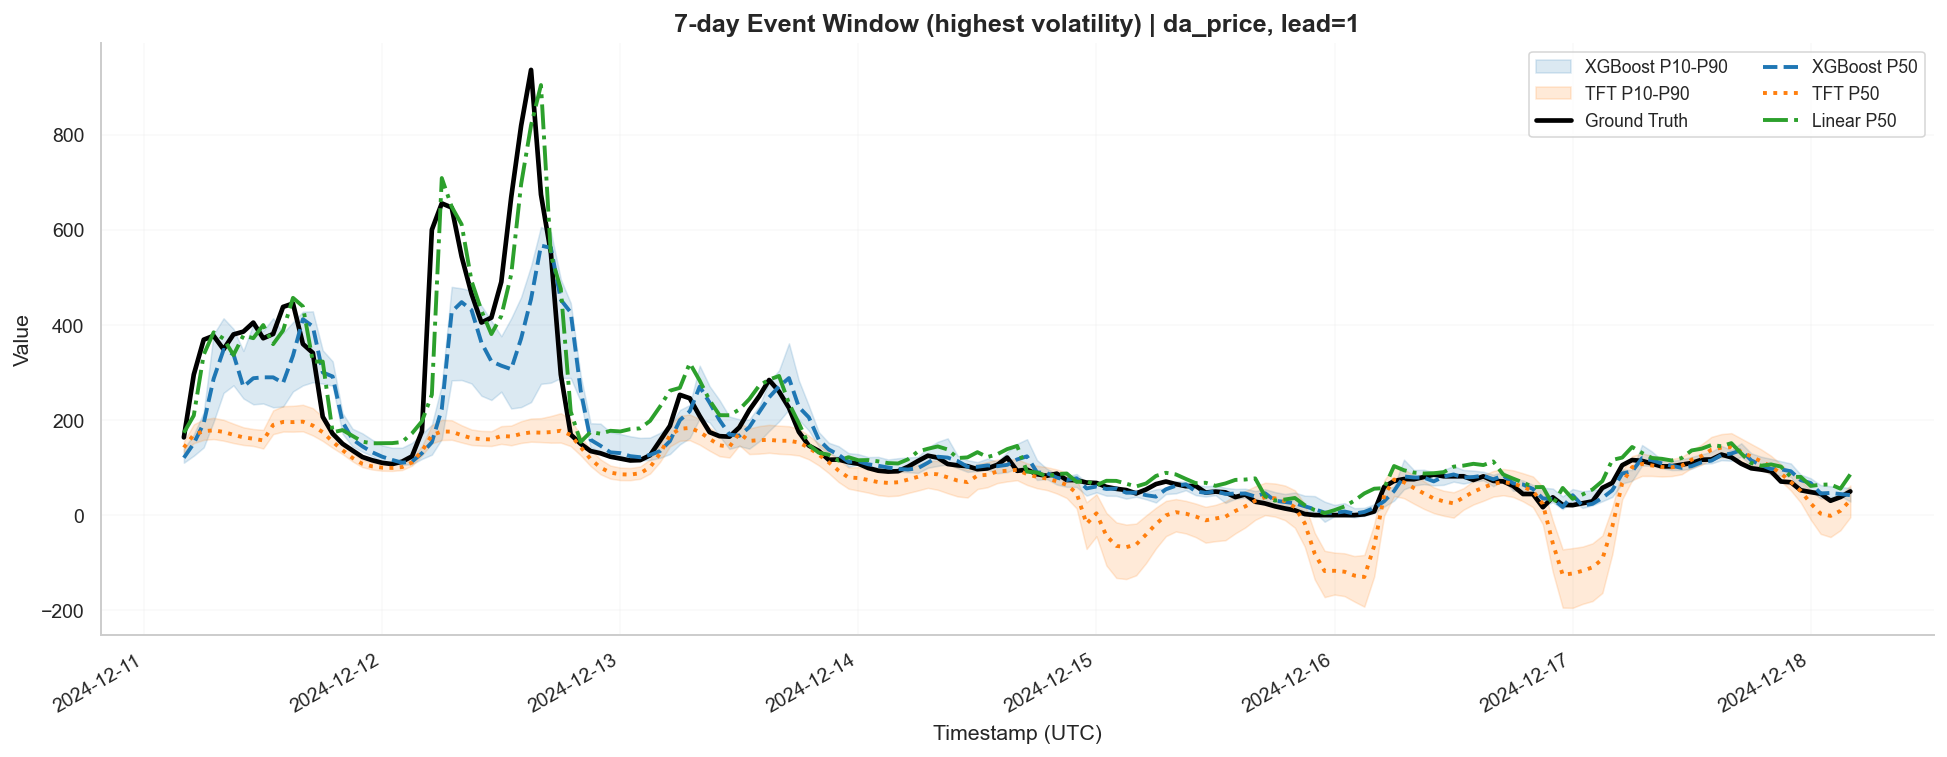

In [35]:
def _highest_vol_window(df: pd.DataFrame, value_col: str = 'y_true', window_days: int = 7) -> tuple[pd.Timestamp, pd.Timestamp]:
    x = df[['timestamp', value_col]].dropna().sort_values('timestamp').copy()
    if x.empty:
        raise ValueError('No data available to determine volatility window.')
    x = x.set_index('timestamp')
    rolling_std = x[value_col].rolling(f'{window_days}D').std()
    end_ts = rolling_std.idxmax()
    if pd.isna(end_ts):
        end_ts = x.index.max()
    start_ts = end_ts - pd.Timedelta(days=window_days)
    return start_ts, end_ts

def plot_time_slice_with_bands(df: pd.DataFrame, target_name: str, start=None, end=None, window_days_if_auto: int = 7):
    d = df.copy().sort_values('timestamp')

    if start is None or end is None:
        start_ts, end_ts = _highest_vol_window(d, value_col='y_true', window_days=window_days_if_auto)
    else:
        start_ts = pd.to_datetime(start, utc=True)
        end_ts = pd.to_datetime(end, utc=True)

    w = d[(d['timestamp'] >= start_ts) & (d['timestamp'] <= end_ts)].copy()
    if w.empty:
        raise ValueError('Selected time window has no rows.')

    fig, ax = plt.subplots(figsize=(14, 5.5))

    for m in MODEL_ORDER:
        c10, c90 = f'{m}_p10', f'{m}_p90'
        if {c10, c90}.issubset(w.columns):
            ax.fill_between(w['timestamp'], w[c10], w[c90], alpha=0.16, color=MODEL_COLORS[m], label=f"{MODEL_LABELS[m]} P10-P90")

    ax.plot(w['timestamp'], w['y_true'], color='black', linewidth=2.4, label='Ground Truth')
    for m in MODEL_ORDER:
        c50 = f'{m}_p50'
        if c50 in w.columns:
            ax.plot(w['timestamp'], w[c50], color=MODEL_COLORS[m], linestyle=MODEL_LINESTYLES[m], linewidth=2.0, label=f"{MODEL_LABELS[m]} P50")

    ax.set_title(f'7-day Event Window (highest volatility) | {target_name}, lead={LEAD_TIME}')
    ax.set_xlabel('Timestamp (UTC)')
    ax.set_ylabel('Value')
    ax.legend(loc='best', ncol=2)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

plot_time_slice_with_bands(df_check, target_name='da_price')


## 3. Residual & Bias Analysis

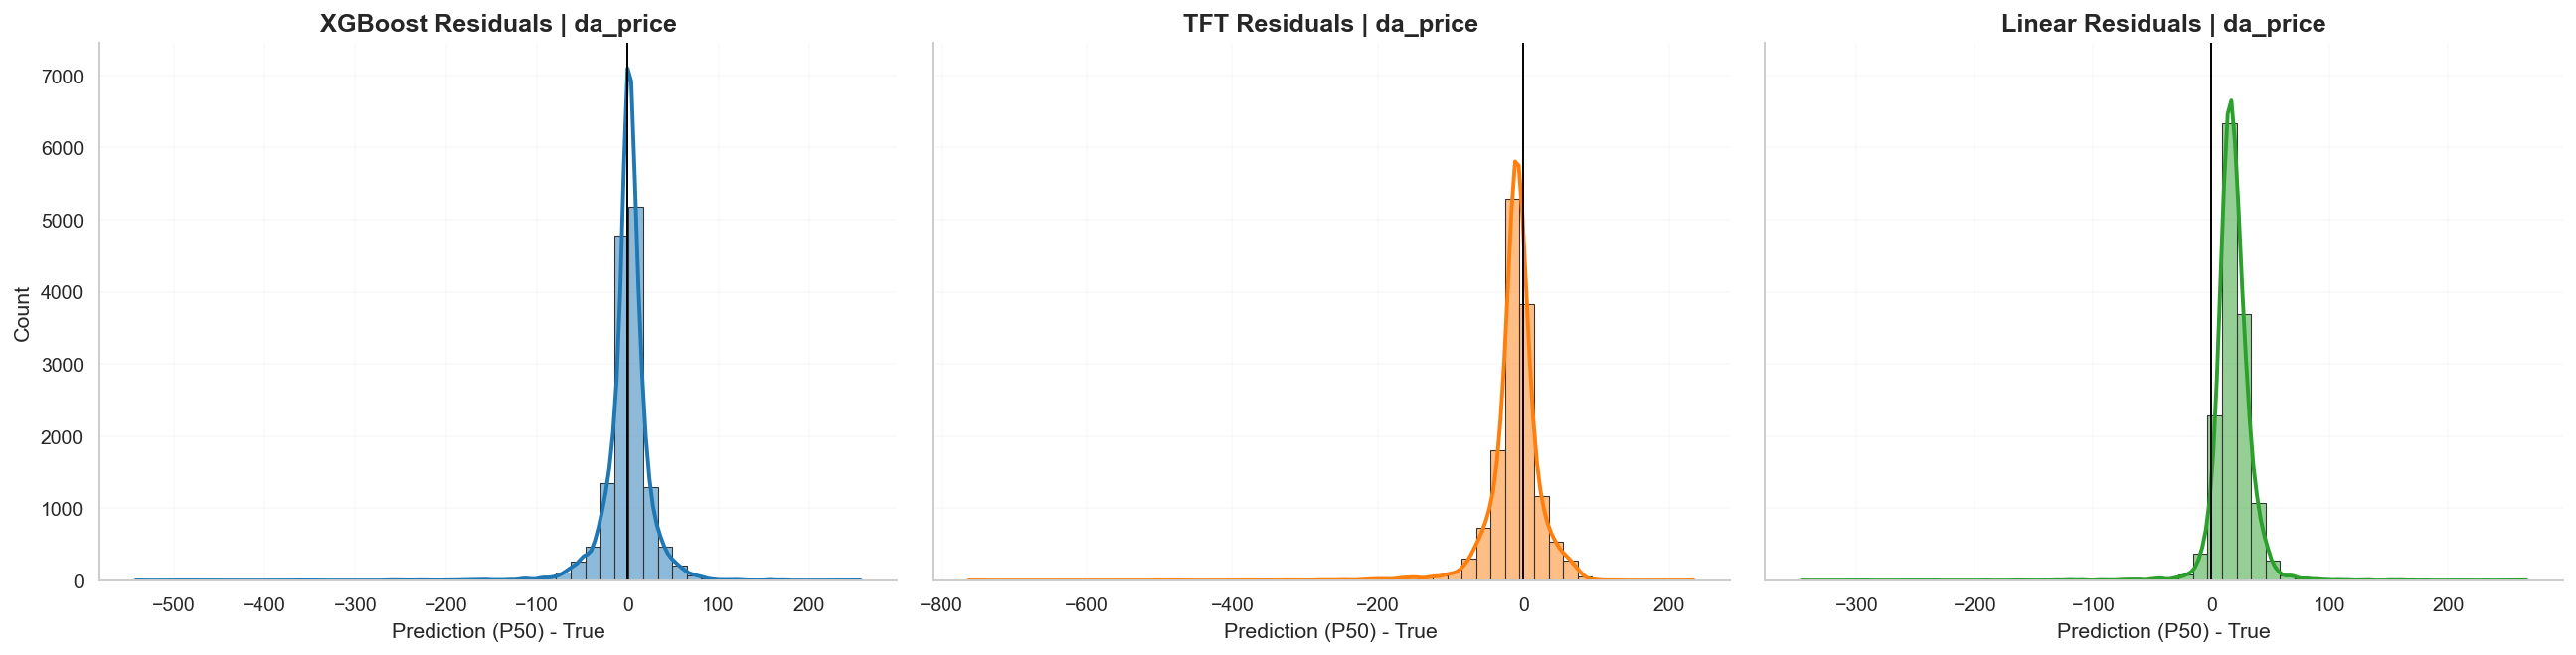

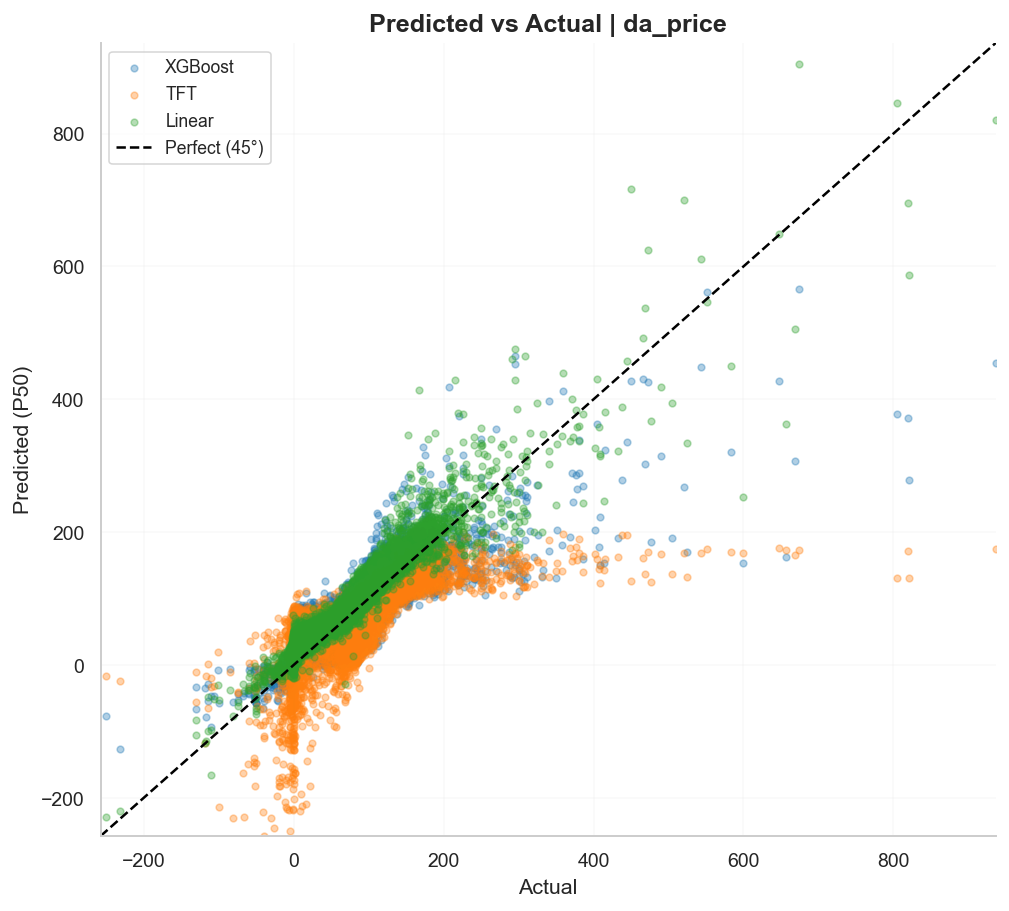

In [36]:
def plot_residual_histograms(df: pd.DataFrame, target_name: str):
    p50_cols = [f'{m}_p50' for m in MODEL_ORDER if f'{m}_p50' in df.columns]
    d = df[['y_true', *p50_cols]].dropna().copy()
    if d.empty:
        print(f'No complete rows available for residual histograms: {target_name}')
        return

    n = len(MODEL_ORDER)
    fig, axes = plt.subplots(1, n, figsize=(6.2 * n, 4.8), sharey=True)
    if n == 1:
        axes = [axes]

    for i, m in enumerate(MODEL_ORDER):
        c50 = f'{m}_p50'
        ax = axes[i]
        if c50 not in d.columns:
            ax.set_axis_off()
            continue
        resid = d[c50] - d['y_true']
        sns.histplot(resid, bins=50, kde=True, color=MODEL_COLORS[m], ax=ax)
        ax.axvline(0, color='black', linewidth=1)
        ax.set_title(f'{MODEL_LABELS[m]} Residuals | {target_name}')
        ax.set_xlabel('Prediction (P50) - True')

    plt.tight_layout()
    plt.show()

def plot_predicted_vs_actual_scatter(df: pd.DataFrame, target_name: str, sample_n: int = 12000, random_state: int = 42):
    p50_cols = [f'{m}_p50' for m in MODEL_ORDER if f'{m}_p50' in df.columns]
    d = df[['y_true', *p50_cols]].dropna().copy()
    if d.empty:
        print(f'No complete rows available for scatter plot: {target_name}')
        return
    if len(d) > sample_n:
        d = d.sample(sample_n, random_state=random_state)

    vals = [d['y_true'].to_numpy(dtype=float)] + [d[c].to_numpy(dtype=float) for c in p50_cols]
    lo = float(np.nanmin([np.nanmin(v) for v in vals]))
    hi = float(np.nanmax([np.nanmax(v) for v in vals]))

    fig, ax = plt.subplots(figsize=(7.3, 6.6))
    for m in MODEL_ORDER:
        c50 = f'{m}_p50'
        if c50 in d.columns:
            ax.scatter(d['y_true'], d[c50], s=12, alpha=0.35, label=MODEL_LABELS[m], color=MODEL_COLORS[m])
    ax.plot([lo, hi], [lo, hi], color='black', linestyle='--', linewidth=1.3, label='Perfect (45°)')
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted (P50)')
    ax.set_title(f'Predicted vs Actual | {target_name}')
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_residual_histograms(df_check, target_name='da_price')
plot_predicted_vs_actual_scatter(df_check, target_name='da_price')


## 4. Temporal Error Heatmaps (Hour × Weekday)

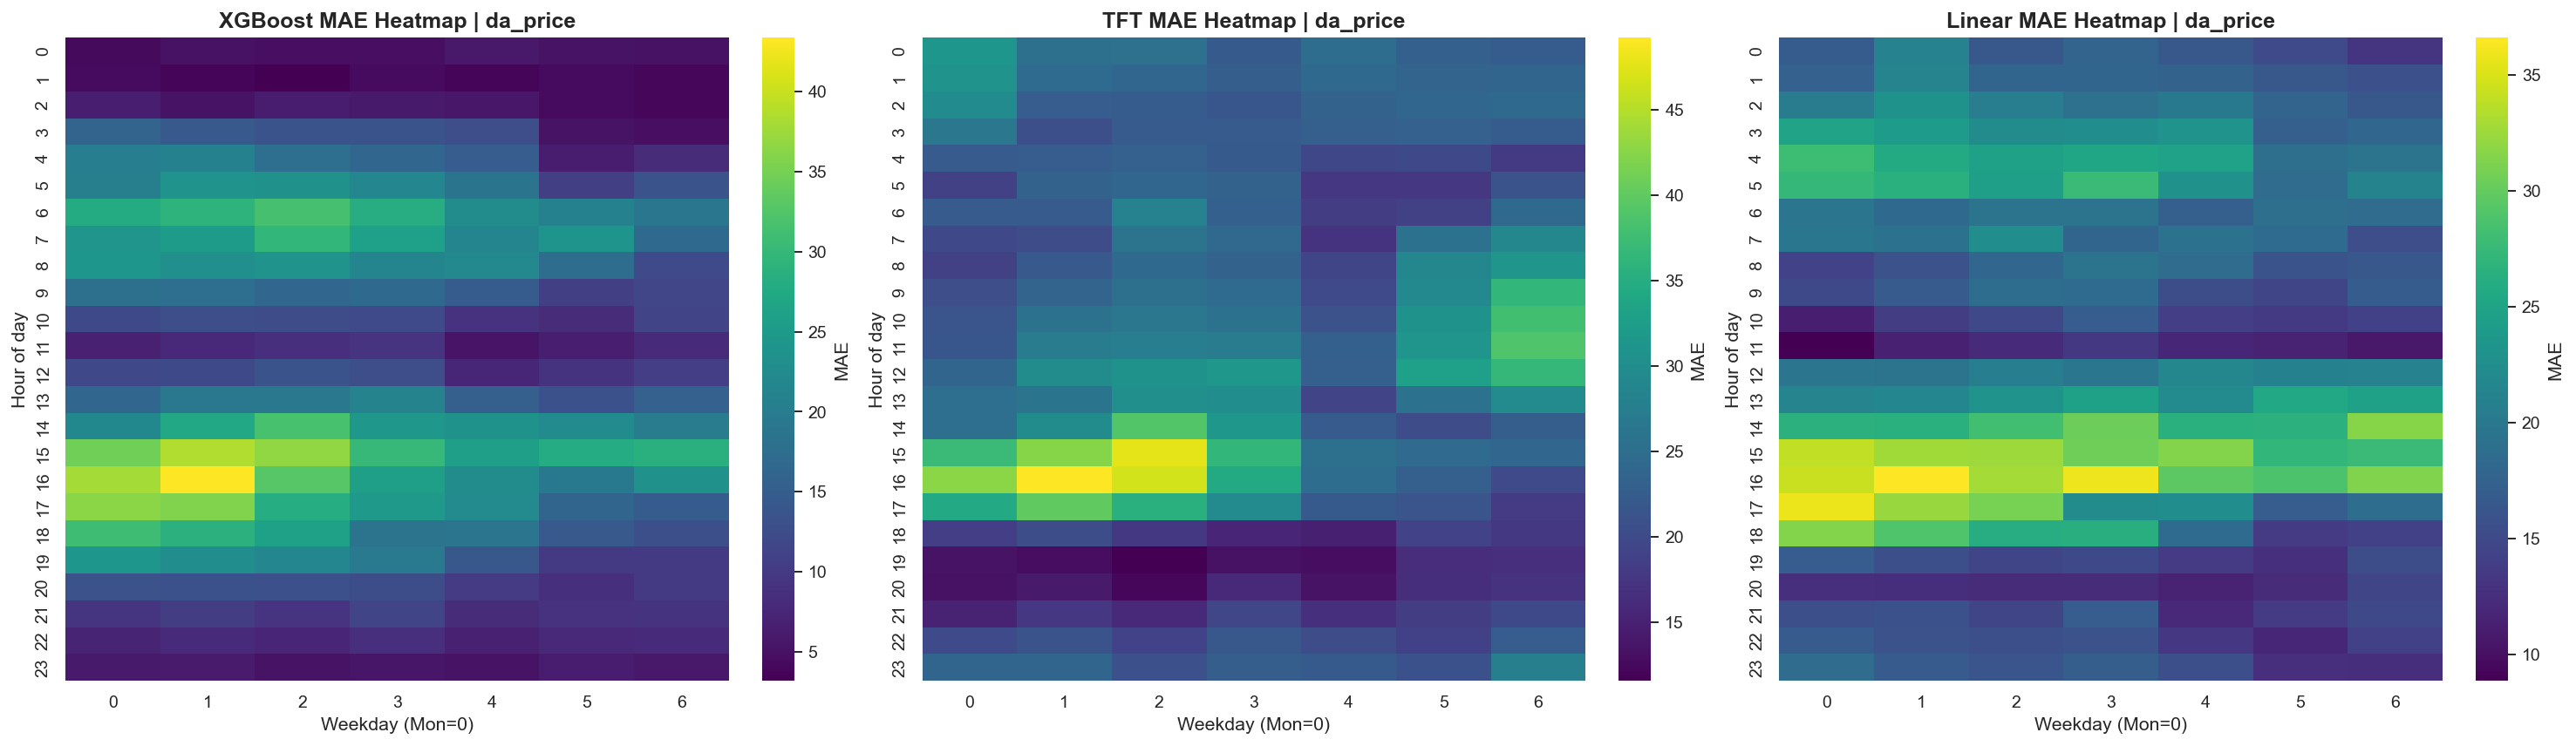

In [37]:
def _mae_heatmap_matrix(df: pd.DataFrame, pred_col: str) -> pd.DataFrame:
    d = df[['timestamp', 'y_true', pred_col]].dropna().copy()
    d['hour'] = d['timestamp'].dt.hour
    d['weekday'] = d['timestamp'].dt.dayofweek
    d['ae'] = (d[pred_col] - d['y_true']).abs()
    piv = d.pivot_table(index='hour', columns='weekday', values='ae', aggfunc='mean')
    piv = piv.reindex(index=range(24), columns=range(7))
    return piv

def plot_temporal_error_heatmaps(df: pd.DataFrame, target_name: str):
    available = [m for m in MODEL_ORDER if f'{m}_p50' in df.columns]
    if not available:
        print(f'No model p50 columns found for heatmaps: {target_name}')
        return

    fig, axes = plt.subplots(1, len(available), figsize=(7 * len(available), 6), constrained_layout=True)
    if len(available) == 1:
        axes = [axes]

    for ax, m in zip(axes, available):
        hm = _mae_heatmap_matrix(df, f'{m}_p50')
        sns.heatmap(hm, cmap='viridis', ax=ax, cbar_kws={'label': 'MAE'})
        ax.set_title(f'{MODEL_LABELS[m]} MAE Heatmap | {target_name}')
        ax.set_xlabel('Weekday (Mon=0)')
        ax.set_ylabel('Hour of day')

    plt.show()

plot_temporal_error_heatmaps(df_check, target_name='da_price')


## 5. Specific Flaw Checks
- Quantile crossing diagnostics
- Activation-rate distribution diagnostics

In [38]:
def quantile_crossing_report(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for model in MODEL_ORDER:
        d = df.copy()
        c10 = f'{model}_p10'
        c40 = f'{model}_p40'
        c60 = f'{model}_p60'
        c90 = f'{model}_p90'

        n = len(d)
        p10_p90 = int(((d[c10] > d[c90]) & d[c10].notna() & d[c90].notna()).sum()) if {c10, c90}.issubset(d.columns) else np.nan
        p40_p60 = int(((d[c40] > d[c60]) & d[c40].notna() & d[c60].notna()).sum()) if {c40, c60}.issubset(d.columns) else np.nan

        rows.append({
            'model': MODEL_LABELS[model],
            'n_rows': n,
            'crossings_p10_gt_p90': p10_p90,
            'crossings_p40_gt_p60': p40_p60,
            'pct_p10_gt_p90': (p10_p90 / n * 100.0) if isinstance(p10_p90, (int, np.integer)) and n > 0 else np.nan,
            'pct_p40_gt_p60': (p40_p60 / n * 100.0) if isinstance(p40_p60, (int, np.integer)) and n > 0 else np.nan,
        })
    return pd.DataFrame(rows)

def plot_activation_rate_distribution(df: pd.DataFrame, target_name: str):
    if 'activation_rate' not in target_name:
        print(f'Skipping activation-rate distribution for target={target_name}')
        return

    available = [m for m in MODEL_ORDER if f'{m}_p50' in df.columns]
    if not available:
        print(f'No model p50 columns found for activation-rate distribution: {target_name}')
        return

    cols = [f'{m}_p50' for m in available]
    d = df[cols].dropna().copy()

    fig, axes = plt.subplots(1, len(available), figsize=(5.8 * len(available), 4.6), sharey=True)
    if len(available) == 1:
        axes = [axes]

    for ax, m in zip(axes, available):
        sns.histplot(d[f'{m}_p50'], bins=50, kde=True, ax=ax, color=MODEL_COLORS[m])
        ax.set_title(f'{MODEL_LABELS[m]} P50 Distribution (Activation Rate)')
        ax.set_xlabel('Predicted activation rate (P50)')

    plt.tight_layout()
    plt.show()

cross_df = quantile_crossing_report(df_check)
cross_df


,model,n_rows,crossings_p10_gt_p90,crossings_p40_gt_p60,pct_p10_gt_p90,pct_p40_gt_p60
0,XGBoost,14402,0.0,0.0,0.0,0.0
1,TFT,14402,0.0,NaN,0.0,NaN
2,Linear,14402,NaN,NaN,NaN,NaN


## Iterative Analysis Over All Targets

In [39]:
def compute_summary_stats(df: pd.DataFrame, target_name: str) -> dict[str, Any]:
    p50_cols = [f'{m}_p50' for m in MODEL_ORDER if f'{m}_p50' in df.columns]
    d = df[['y_true', *p50_cols]].dropna().copy()
    if d.empty:
        out = {'target': target_name, 'n': 0}
        for m in MODEL_ORDER:
            out[f'{m}_mae'] = np.nan
            out[f'{m}_rmse'] = np.nan
        out['tft_minus_xgb_mae'] = np.nan
        out['linear_minus_xgb_mae'] = np.nan
        return out

    out = {'target': target_name, 'n': int(len(d))}
    for m in MODEL_ORDER:
        c50 = f'{m}_p50'
        if c50 in d.columns:
            err = d[c50] - d['y_true']
            out[f'{m}_mae'] = float(np.mean(np.abs(err)))
            out[f'{m}_rmse'] = float(np.sqrt(np.mean(np.square(err))))
        else:
            out[f'{m}_mae'] = np.nan
            out[f'{m}_rmse'] = np.nan

    out['tft_minus_xgb_mae'] = out['tft_mae'] - out['xgb_mae'] if np.isfinite(out['tft_mae']) and np.isfinite(out['xgb_mae']) else np.nan
    out['linear_minus_xgb_mae'] = out['linear_mae'] - out['xgb_mae'] if np.isfinite(out['linear_mae']) and np.isfinite(out['xgb_mae']) else np.nan
    return out

def run_full_target_deepdive(targets=None, split: str = SPLIT, lead_time: int = LEAD_TIME, plot_each: bool = True) -> pd.DataFrame:
    targets = targets or TARGET_ORDER
    rows = []

    for target_name in targets:
        try:
            df = load_and_align_predictions(
                target_name=target_name,
                xgb_run_dir=XGB_RUN_DIR,
                tft_run_dir=TFT_RUN_DIR,
                linear_run_dir=LINEAR_RUN_DIR,
                split=split,
                lead_time=lead_time,
                truth_path_override=TRUTH_PATH_OVERRIDE,
            )
            rows.append(compute_summary_stats(df, target_name=target_name))

            if plot_each:
                plot_time_slice_with_bands(df, target_name=target_name)
                plot_residual_histograms(df, target_name=target_name)
                plot_predicted_vs_actual_scatter(df, target_name=target_name)
                plot_temporal_error_heatmaps(df, target_name=target_name)
                display(quantile_crossing_report(df))
                plot_activation_rate_distribution(df, target_name=target_name)
        except Exception as e:
            rows.append({'target': target_name, 'n': 0, 'error': str(e)})

    return pd.DataFrame(rows)

summary_df = run_full_target_deepdive(plot_each=False)
summary_df


,target,n,xgb_mae,xgb_rmse,tft_mae,tft_rmse,linear_mae,linear_rmse,tft_minus_xgb_mae,linear_minus_xgb_mae
0,da_price,14402,15.625912,27.630435,24.010580,39.744278,19.828477,24.955262,8.384669,4.202566
1,afrr_activation_price_pos,14402,401.684037,556.025992,241.237436,388.871718,270.954233,403.904092,-160.446600,-130.729803
2,afrr_activation_price_neg,14402,211.102209,315.996030,172.821155,271.490734,188.812083,280.581396,-38.281054,-22.290126
3,afrr_capacity_price_pos,14402,11.775598,73.289315,13.359920,74.580570,15.344398,61.966642,1.584322,3.568801
4,afrr_capacity_price_neg,14402,9.771775,47.035082,13.805789,55.311863,20.045398,42.277168,4.034014,10.273623
5,afrr_activation_rate_pos,14402,0.005674,0.011210,0.005591,0.011305,0.008615,0.011518,-0.000083,0.002941
6,afrr_activation_rate_neg,14402,0.005317,0.009538,0.005256,0.010304,0.007037,0.010837,-0.000061,0.001721


## Focused Plot Runner
Use this for one target when writing thesis figures.

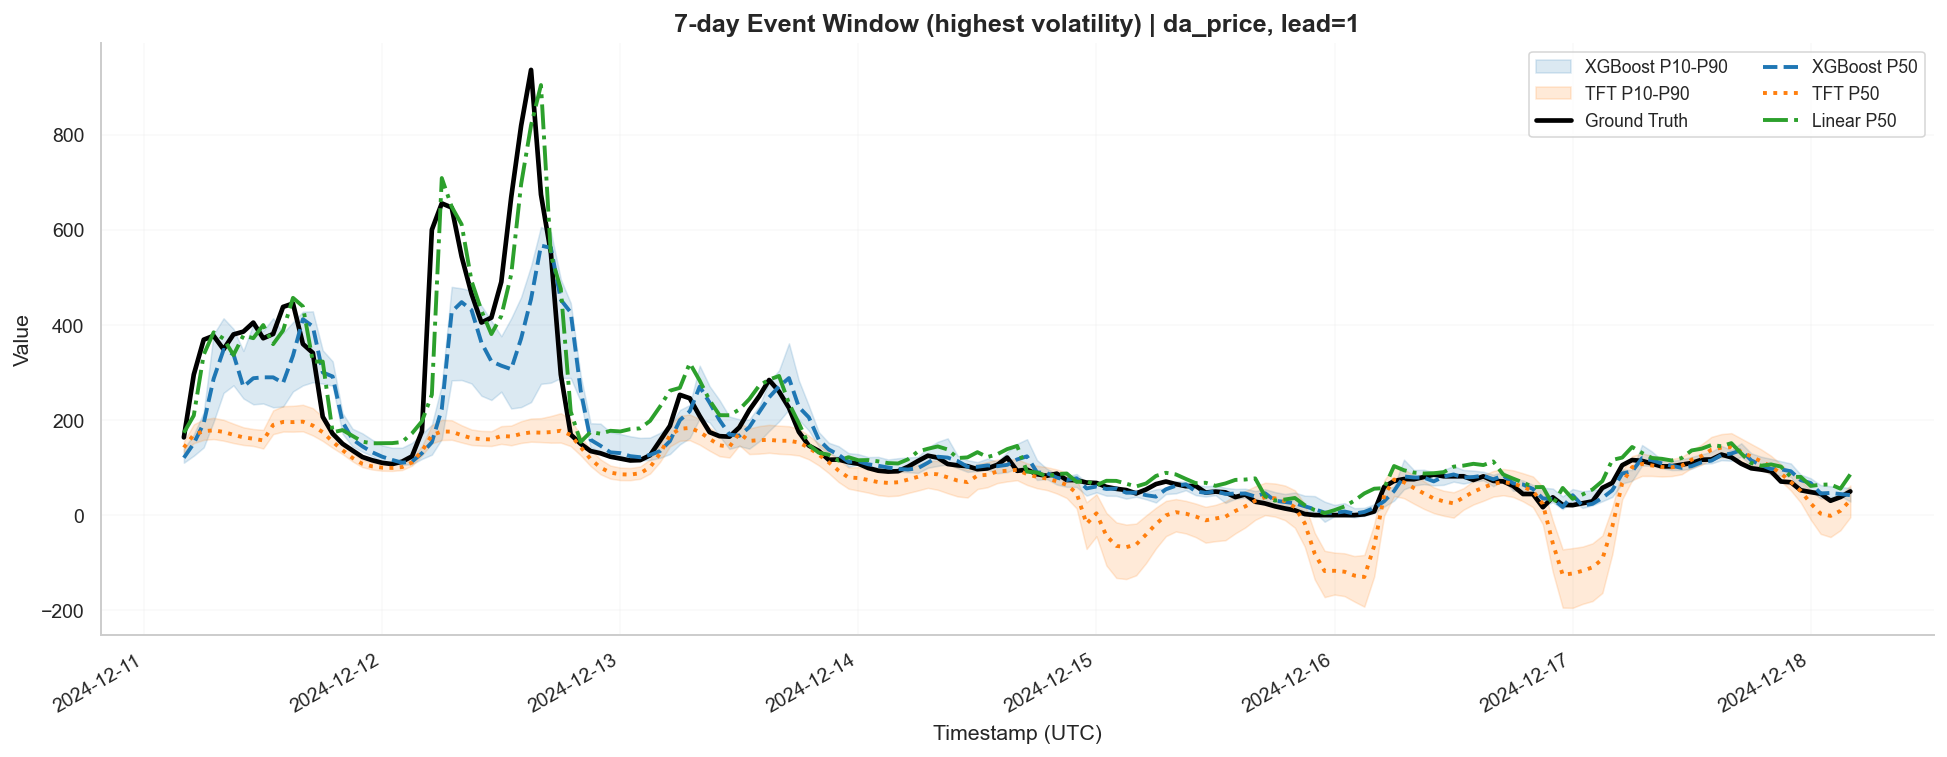

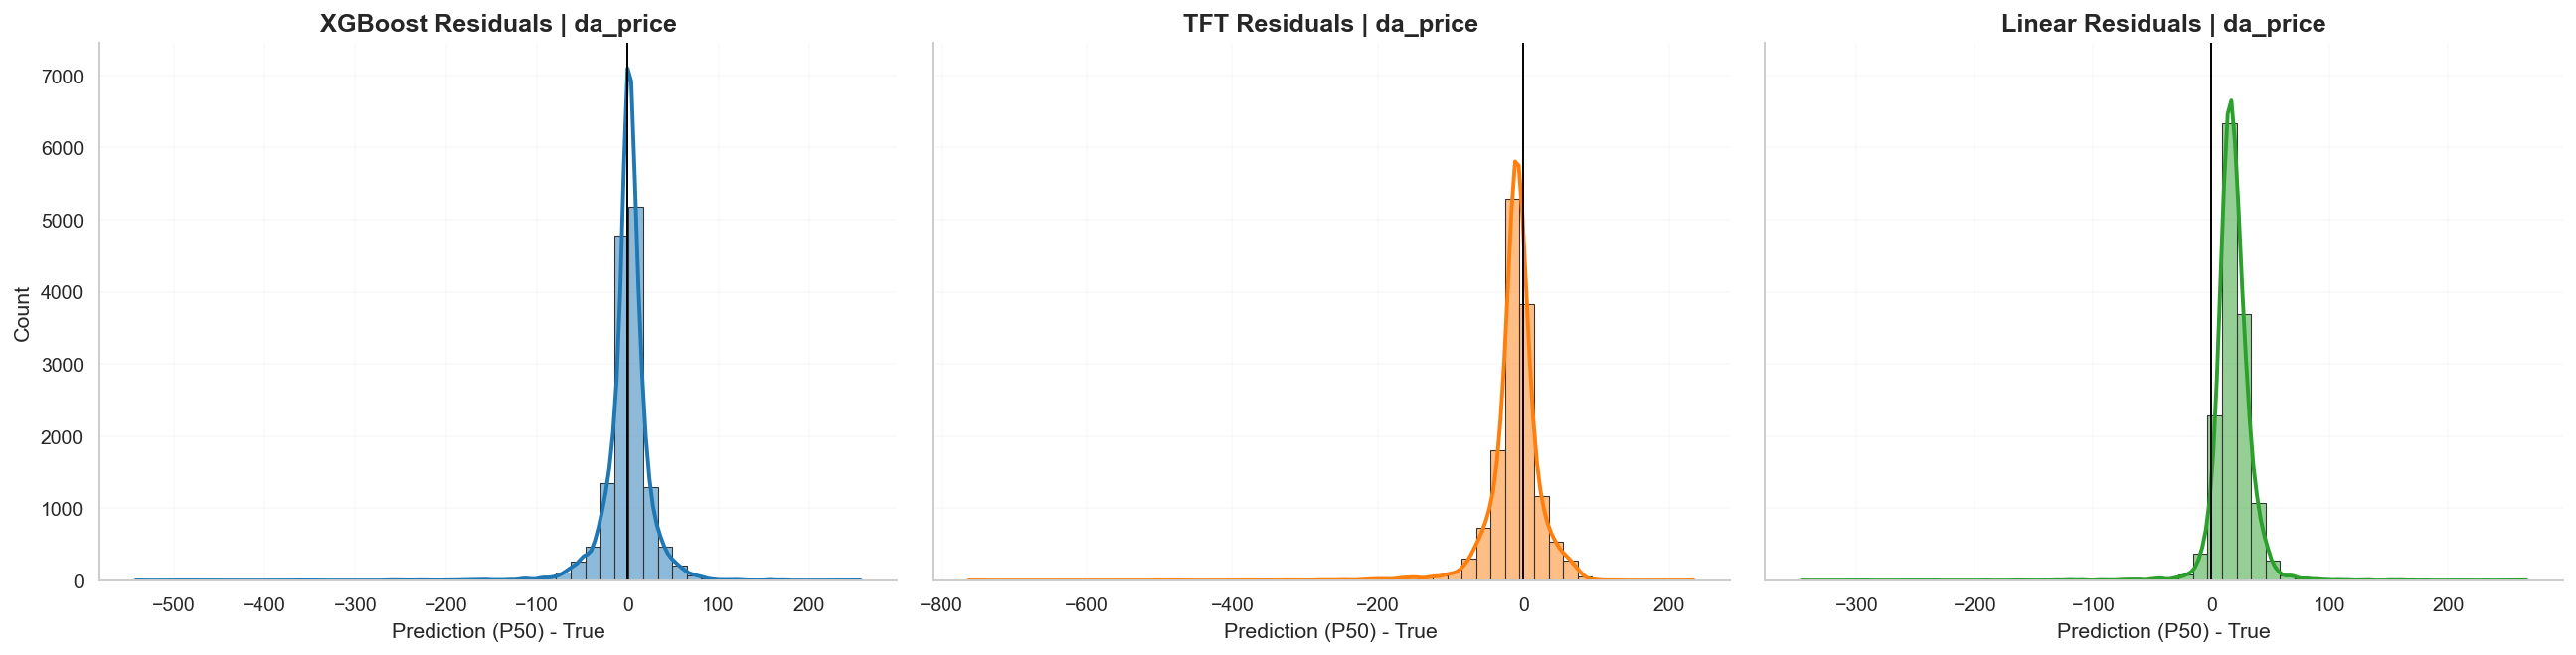

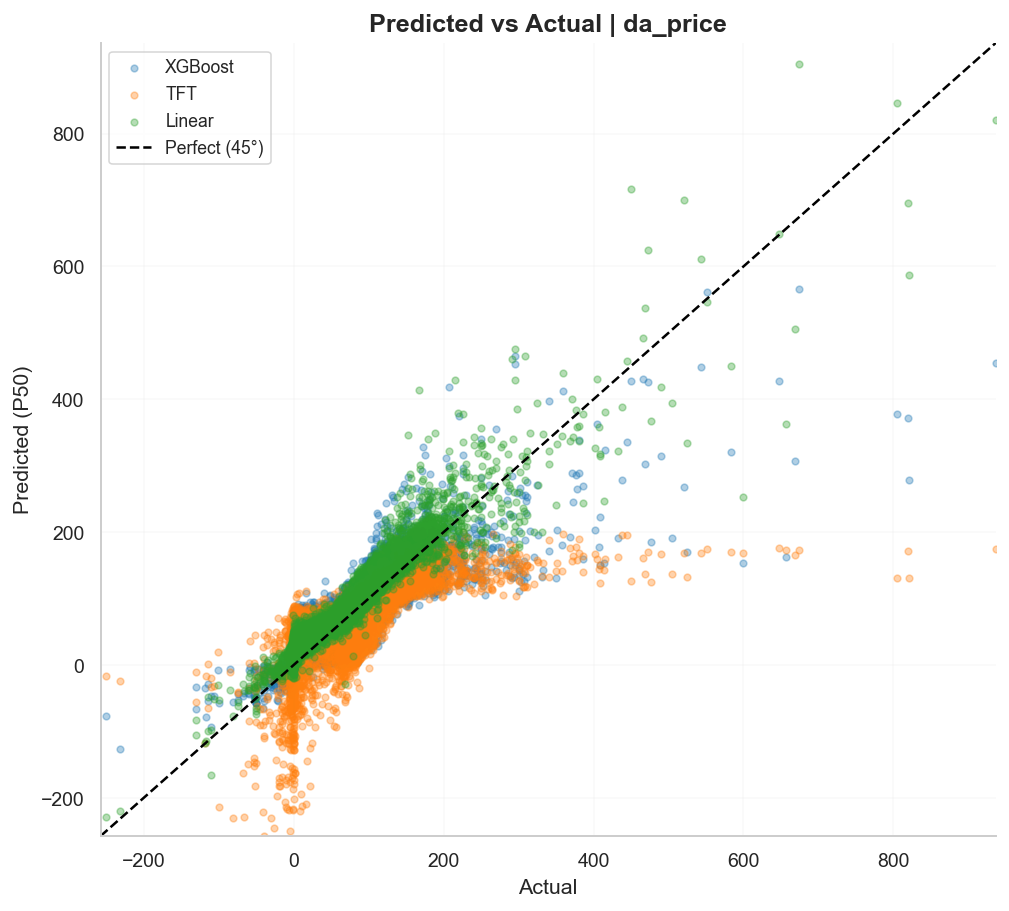

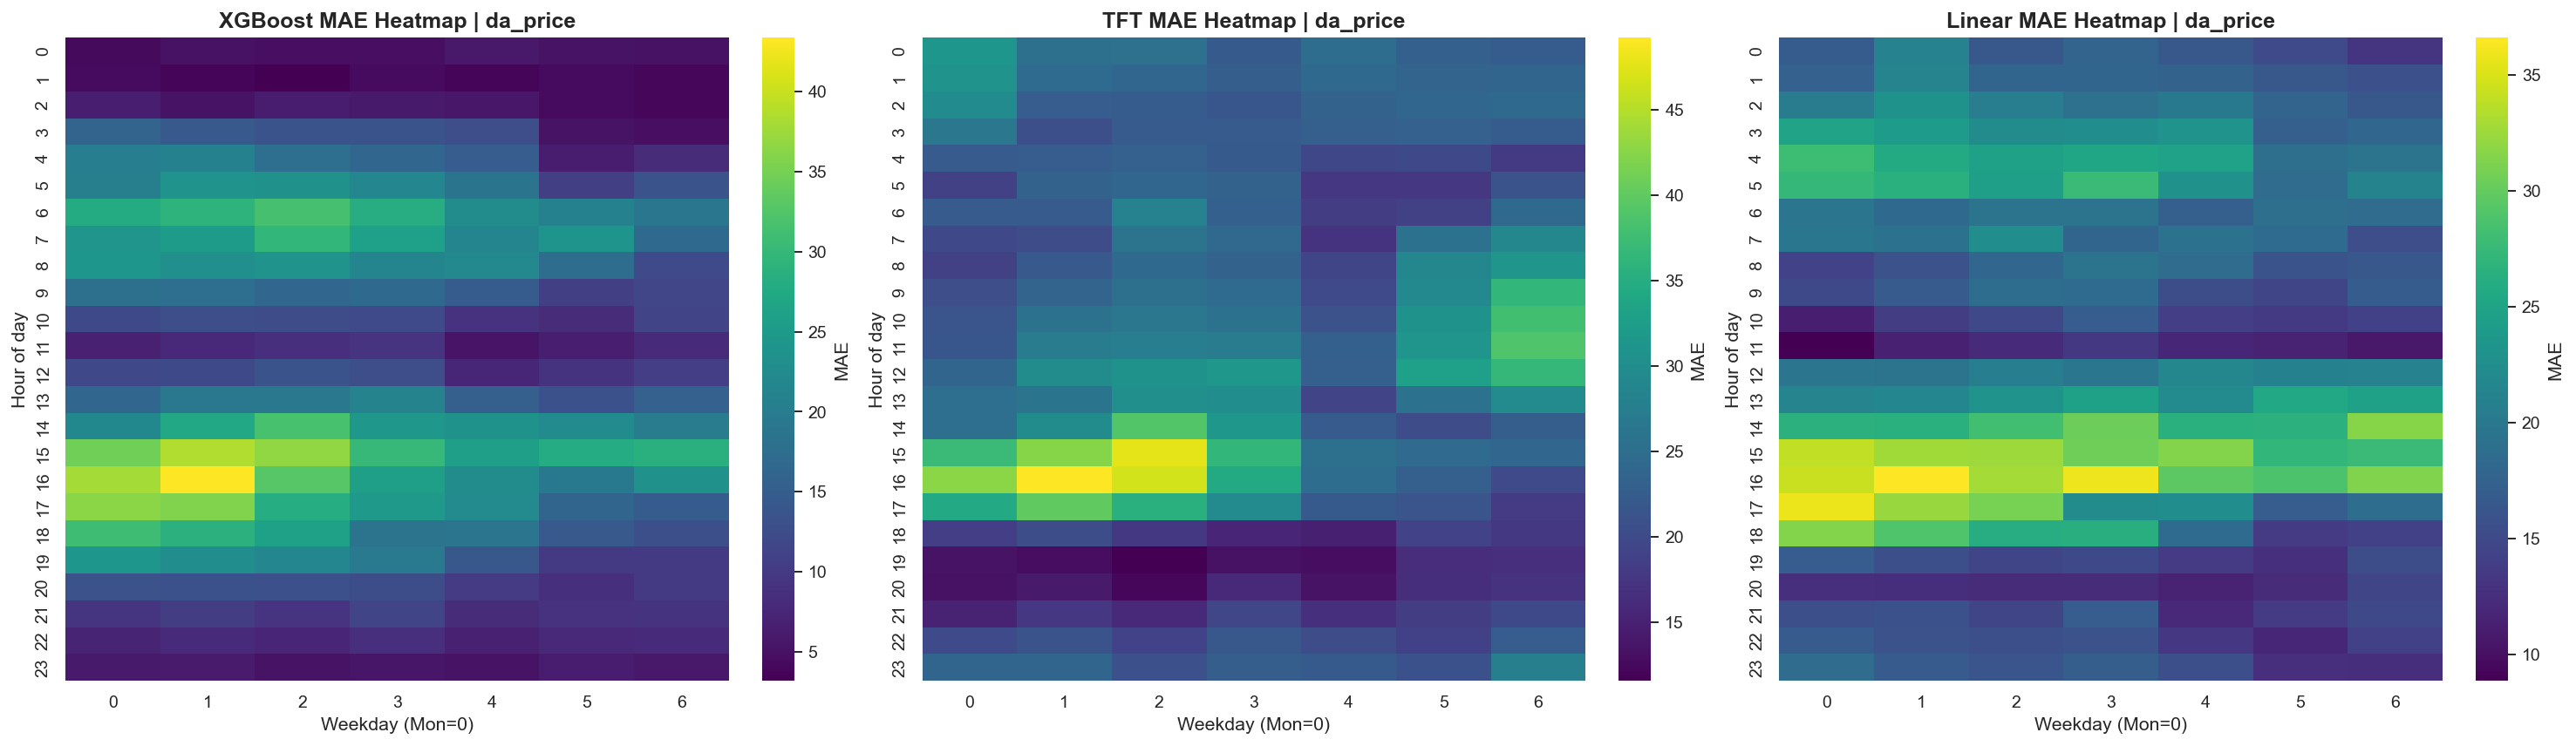

,model,n_rows,crossings_p10_gt_p90,crossings_p40_gt_p60,pct_p10_gt_p90,pct_p40_gt_p60
0,XGBoost,14402,0.0,0.0,0.0,0.0
1,TFT,14402,0.0,NaN,0.0,NaN
2,Linear,14402,NaN,NaN,NaN,NaN


Skipping activation-rate distribution for target=da_price


In [40]:
target_name = 'da_price'  # change as needed

df_target = load_and_align_predictions(
    target_name=target_name,
    xgb_run_dir=XGB_RUN_DIR,
    tft_run_dir=TFT_RUN_DIR,
    linear_run_dir=LINEAR_RUN_DIR,
    split=SPLIT,
    lead_time=LEAD_TIME,
    truth_path_override=TRUTH_PATH_OVERRIDE,
)

plot_time_slice_with_bands(df_target, target_name=target_name)
plot_residual_histograms(df_target, target_name=target_name)
plot_predicted_vs_actual_scatter(df_target, target_name=target_name)
plot_temporal_error_heatmaps(df_target, target_name=target_name)
display(quantile_crossing_report(df_target))
plot_activation_rate_distribution(df_target, target_name=target_name)
